In [1]:
# !pip install wrds
# !pip install swig
# !pip install -q condacolab
# import condacolab
# condacolab.install()
# !apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
# !pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
# !pip install stockstats
# !pip install tushare
# !git clone https://github.com/AI4Finance-Foundation/FinRL-Meta

In [2]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd 
from IPython import display

display.set_matplotlib_formats("svg")
import sys
sys.path.append("./FinRL-Meta")
from meta import config 
from meta.data_processor import DataProcessor 
from main import check_and_make_directories 
from meta.data_processors.tushare import Tushare, ReturnPlotter 
from meta.env_stock_trading.env_stocktrading_China_A_shares import StockTradingEnv 
from agents.stablebaselines3_models import DRLAgent 
import os 
from typing import List 
from argparse import ArgumentParser 
from meta import config 
from meta.config_tickers import DOW_30_TICKER 
from meta.config import ( DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR, INDICATORS, TRAIN_START_DATE, TRAIN_END_DATE, TEST_START_DATE, TEST_END_DATE, TRADE_START_DATE, TRADE_END_DATE, ERL_PARAMS, RLlib_PARAMS, SAC_PARAMS, ALPACA_API_KEY, ALPACA_API_SECRET, ALPACA_API_BASE_URL, )

import pyfolio
from pyfolio import timeseries

pd.options.display.max_columns = None

ALL Modules have been imported!


## 创建目录

In [3]:
import os

''' 
use check_and_make_directories() to replace the following

if not os.path.exists("./datasets"): 
  os.makedirs("./datasets") 
if not os.path.exists("./trained_models"): 
  os.makedirs("./trained_models") 
if not os.path.exists("./tensorboard_log"): 
  os.makedirs("./tensorboard_log") 
if not os.path.exists("./results"): 
  os.makedirs("./results") 
'''

check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])
TRAINED_MODEL_DIR=TRAINED_MODEL_DIR+"/"

## 数据下载，特征工程

In [4]:
ticker_list = ['600000.SH', '600009.SH', '600016.SH', '600028.SH', '600030.SH', 
               '600031.SH', '600036.SH', '600050.SH', '600104.SH', '600196.SH', 
               '600276.SH', '600309.SH', '600519.SH', '600547.SH', '600570.SH']

TRAIN_START_DATE = '2015-01-01' 
TRAIN_END_DATE= '2019-08-01' 
TRADE_START_DATE = '2019-08-01' 
TRADE_END_DATE = '2020-01-01'

TIME_INTERVAL = "1d" 
kwargs = {} 
# tushare token
kwargs['token'] = '' 
p = DataProcessor(data_source='tushare', start_date=TRAIN_START_DATE, end_date=TRADE_END_DATE, time_interval=TIME_INTERVAL, **kwargs)

tushare successfully connected


### 数据下载、清洗

In [5]:
p.download_data(ticker_list=ticker_list)
p.clean_data()
p.fillna()

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:29<00:00,  1.98s/it]

Download complete! Dataset saved to ./data/dataset.csv. 
Shape of DataFrame: (17960, 8)
Shape of DataFrame:  (18315, 8)


### 新增技术指标

In [6]:
p.add_technical_indicator(config.INDICATORS) 
p.fillna()
save_obj(p, "./data/强化学习数据")
#print(f"p.dataframe: {p.dataframe}")

tech_indicator_list:  ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']
indicator:  macd
indicator:  boll_ub
indicator:  boll_lb
indicator:  rsi_30
indicator:  cci_30
indicator:  dx_30
indicator:  close_30_sma
indicator:  close_60_sma
Succesfully add technical indicators
Shape of DataFrame:  (18270, 17)


## 数据集分割

In [ ]:
p = load_obj("./data/强化学习数据")

In [7]:
df = p.dataframe
train = p.data_split(df, TRAIN_START_DATE, TRAIN_END_DATE) 

len(train.tic.unique()): 15


In [11]:
stock_dimension = len(train.tic.unique()) 
state_space = stock_dimension * (len(config.INDICATORS) + 2) + 1 

print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 15, State Space: 151


## 训练

In [12]:
train = train.rename(columns={"time":'date'})
env_kwargs = { "stock_dim": stock_dimension, "hmax": 1000, "initial_amount": 1000000, "buy_cost_pct": 6.87e-5, "sell_cost_pct": 1.0687e-3, "reward_scaling": 1e-4, "state_space": state_space, "action_space": stock_dimension, "tech_indicator_list": config.INDICATORS, "print_verbosity": 1, "initial_buy": True, "hundred_each_trade": True }

e_train_gym = StockTradingEnv(df=train, **env_kwargs)

In [13]:
env_train, _ = e_train_gym.get_sb_env() 

print(f"print(type(env_train)): {print(type(env_train))}")

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>
print(type(env_train)): None


### DDPG

In [14]:
agent = DRLAgent(env=env_train) 
DDPG_PARAMS = { "batch_size": 256, "buffer_size": 50000, "learning_rate": 0.0005, "action_noise": "normal", } 
POLICY_KWARGS = dict(net_arch=dict(pi=[64, 64], qf=[400, 300])) 
model_ddpg = agent.get_model("ddpg", model_kwargs=DDPG_PARAMS, policy_kwargs=POLICY_KWARGS)

trained_ddpg = agent.train_model(model=model_ddpg, tb_log_name='ddpg', total_timesteps=10000)

{'batch_size': 256, 'buffer_size': 50000, 'learning_rate': 0.0005, 'action_noise': NormalActionNoise(mu=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma=[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1])}
Using cuda device
Logging to tensorboard_log/ddpg\ddpg_5
Episode: 2
day: 1112, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 1384219.22
total_reward: 384219.22
total_cost: 15560.93
total_trades: 16677
Sharpe: 0.385
Episode: 3
day: 1112, episode: 3
begin_total_asset: 1000000.00
end_total_asset: 1507153.20
total_reward: 507153.20
total_cost: 456.80
total_trades: 16680
Sharpe: 0.466
Episode: 4
day: 1112, episode: 4
begin_total_asset: 1000000.00
end_total_asset: 1490436.55
total_reward: 490436.55
total_cost: 442.45
total_trades: 16680
Sharpe: 0.463
Episode: 5
day: 1112, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 1502312.55
total_reward: 502312.55
total_cost: 442.45
total_trades: 16680
Sharpe: 0.468
----------------------------------
| time/     

In [15]:
trained_ddpg.save(TRAINED_MODEL_DIR + "agent_ddpg")

### A2C

In [16]:
agent = DRLAgent(env=env_train) 
model_a2c = agent.get_model("a2c")

trained_a2c = agent.train_model(model=model_a2c, tb_log_name='a2c', total_timesteps=50000)

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cuda device
Logging to tensorboard_log/a2c\a2c_3
----------------------------------------
| time/                 |              |
|    fps                | 213          |
|    iterations         | 100          |
|    time_elapsed       | 2            |
|    total_timesteps    | 500          |
| train/                |              |
|    entropy_loss       | -21.4        |
|    explained_variance | 0.0335       |
|    learning_rate      | 0.0007       |
|    n_updates          | 99           |
|    policy_loss        | 10           |
|    reward             | -0.022232348 |
|    std                | 1.01         |
|    value_loss         | 0.695        |
----------------------------------------
-------------------------------------
| time/                 |           |
|    fps                | 204       |
|    iterations         | 200       |
|    time_elapsed       | 4         |
|    total_timesteps    | 1000      |
| t

In [17]:
trained_a2c.save(TRAINED_MODEL_DIR + "agent_a2c")

### Agent 3: PPO

In [18]:
agent = DRLAgent(env = env_train)
PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo",model_kwargs = PPO_PARAMS)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cuda device


In [19]:
trained_ppo = agent.train_model(model=model_ppo, 
                             tb_log_name='ppo',
                             total_timesteps=200000)

Logging to tensorboard_log/ppo\ppo_1
Episode: 57
day: 1112, episode: 57
begin_total_asset: 1000000.00
end_total_asset: 663509.11
total_reward: -336490.89
total_cost: 116814.58
total_trades: 16666
Sharpe: -0.170
------------------------------------
| time/              |             |
|    fps             | 254         |
|    iterations      | 1           |
|    time_elapsed    | 8           |
|    total_timesteps | 2048        |
| train/             |             |
|    reward          | -0.57966185 |
------------------------------------
Episode: 58
day: 1112, episode: 58
begin_total_asset: 1000000.00
end_total_asset: 1086791.36
total_reward: 86791.36
total_cost: 135308.64
total_trades: 16662
Sharpe: 0.209
Episode: 59
day: 1112, episode: 59
begin_total_asset: 1000000.00
end_total_asset: 291975.84
total_reward: -708024.16
total_cost: 54906.16
total_trades: 16668
Sharpe: -0.224
----------------------------------------
| time/                   |            |
|    fps                  | 2

In [20]:
trained_ppo.save(TRAINED_MODEL_DIR + "agent_ppo")

### Agent 4: TD3

In [21]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {"batch_size": 100, 
              "buffer_size": 1000000, 
              "learning_rate": 0.001}

model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)

{'batch_size': 100, 'buffer_size': 1000000, 'learning_rate': 0.001}
Using cuda device


In [22]:
trained_td3 = agent.train_model(model=model_td3, 
                             tb_log_name='td3',
                             total_timesteps=50000)

Logging to tensorboard_log/td3\td3_1
Episode: 238
day: 1112, episode: 238
begin_total_asset: 1000000.00
end_total_asset: 2000842.31
total_reward: 1000842.31
total_cost: 12055.83
total_trades: 16679
Sharpe: 0.680
Episode: 239
day: 1112, episode: 239
begin_total_asset: 1000000.00
end_total_asset: 1231155.19
total_reward: 231155.19
total_cost: 204.81
total_trades: 16680
Sharpe: 0.471
Episode: 240
day: 1112, episode: 240
begin_total_asset: 1000000.00
end_total_asset: 999887.83
total_reward: -112.17
total_cost: 112.17
total_trades: 16680
Sharpe: 0.370
Episode: 241
day: 1112, episode: 241
begin_total_asset: 1000000.00
end_total_asset: 999887.83
total_reward: -112.17
total_cost: 112.17
total_trades: 16680
Sharpe: 0.370
----------------------------------
| time/              |           |
|    episodes        | 4         |
|    fps             | 124       |
|    time_elapsed    | 35        |
|    total_timesteps | 4452      |
| train/             |           |
|    actor_loss      | 81.4      

In [78]:
trained_td3.save(TRAINED_MODEL_DIR + "agent_td3")

### Agent 5: SAC

In [24]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 128,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

model_sac = agent.get_model("sac",model_kwargs = SAC_PARAMS)

{'batch_size': 128, 'buffer_size': 100000, 'learning_rate': 0.0001, 'learning_starts': 100, 'ent_coef': 'auto_0.1'}
Using cuda device


In [25]:
trained_sac = agent.train_model(model=model_sac, 
                             tb_log_name='sac',
                             total_timesteps=70000)

Logging to tensorboard_log/sac\sac_1
Episode: 284
day: 1112, episode: 284
begin_total_asset: 1000000.00
end_total_asset: 1598420.61
total_reward: 598420.61
total_cost: 13839.54
total_trades: 16678
Sharpe: 0.470
Episode: 285
day: 1112, episode: 285
begin_total_asset: 1000000.00
end_total_asset: 1529997.33
total_reward: 529997.33
total_cost: 609.67
total_trades: 16680
Sharpe: 0.455
Episode: 286
day: 1112, episode: 286
begin_total_asset: 1000000.00
end_total_asset: 1022506.14
total_reward: 22506.14
total_cost: 258.86
total_trades: 16680
Sharpe: 0.394
Episode: 287
day: 1112, episode: 287
begin_total_asset: 1000000.00
end_total_asset: 741587.24
total_reward: -258412.76
total_cost: 3133.76
total_trades: 16680
Sharpe: 0.230
-----------------------------------
| time/              |            |
|    episodes        | 4          |
|    fps             | 56         |
|    time_elapsed    | 78         |
|    total_timesteps | 4452       |
| train/             |            |
|    actor_loss      

In [26]:
trained_sac.save(TRAINED_MODEL_DIR + "agent_sac")

## 预测

In [27]:
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from pyfolio import timeseries
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline,convert_daily_return_to_pyfolio_ts

In [28]:
trained_ddpg = DDPG.load(TRAINED_MODEL_DIR + "agent_ddpg")
trained_a2c = A2C.load(TRAINED_MODEL_DIR + "agent_a2c")
trained_ppo = PPO.load(TRAINED_MODEL_DIR + "agent_ppo")
trained_td3 = TD3.load(TRAINED_MODEL_DIR + "agent_td3")
trained_sac = SAC.load(TRAINED_MODEL_DIR + "agent_sac")

In [29]:
trade = p.data_split(p.dataframe, TRADE_START_DATE, TRADE_END_DATE) 
trade = trade.rename(columns={"time":'date'})
env_kwargs = { "stock_dim": stock_dimension, "hmax": 1000, "initial_amount": 1000000, "buy_cost_pct": 6.87e-5, "sell_cost_pct": 1.0687e-3, "reward_scaling": 1e-4, "state_space": state_space, "action_space": stock_dimension, "tech_indicator_list": config.INDICATORS, "print_verbosity": 1, "initial_buy": False, "hundred_each_trade": True } 
e_trade_gym = StockTradingEnv(df=trade, **env_kwargs)

In [30]:
import datetime
df_return_dict, df_cumpod_dict, df_action_dict = {}, {}, {}
for model, model_name in zip([trained_ddpg, trained_a2c, trained_ppo, trained_td3, trained_sac], 
                             ["DDPG", "A2C", "PPO", "TD3", "SAC"]):
    df_account_value, df_actions = DRLAgent.DRL_prediction(model=model, environment=e_trade_gym)
    daily_return = get_daily_return(df_account_value, value_col_name='account_value')
    # import pandas as pd
    # df_daily_return = pd.read_csv("df_daily_return.csv", index_col=0)
    # 收益率
    df_daily_return = daily_return.fillna(0).reset_index()
    # df_daily_return = df_daily_return.rename(columns={"time":"date"})
    df_daily_return['date'] = df_daily_return['date'].apply(lambda x:datetime.datetime.strftime(x, '%Y-%m-%d'))
    df_return_dict[model_name] = df_daily_return
    # 累计收益率
    cumpod =(df_daily_return.daily_return+1).cumprod()-1
    df_cumpod_dict[model_name] = cumpod
    df_action_dict[model_name] = df_actions

Episode: 2
day: 103, episode: 2
begin_total_asset: 1000000.00
end_total_asset: 1008025.33
total_reward: 8025.33
total_cost: 68.67
total_trades: 721
Sharpe: 0.201
hit end!
Episode: 5
day: 103, episode: 5
begin_total_asset: 1000000.00
end_total_asset: 1076662.56
total_reward: 76662.56
total_cost: 8874.44
total_trades: 548
Sharpe: 1.497
hit end!
Episode: 8
day: 103, episode: 8
begin_total_asset: 1000000.00
end_total_asset: 1156053.67
total_reward: 156053.67
total_cost: 15310.33
total_trades: 1224
Sharpe: 2.219
hit end!
Episode: 11
day: 103, episode: 11
begin_total_asset: 1000000.00
end_total_asset: 1164129.32
total_reward: 164129.32
total_cost: 68.68
total_trades: 721
Sharpe: 1.623
hit end!
Episode: 14
day: 103, episode: 14
begin_total_asset: 1000000.00
end_total_asset: 1084266.43
total_reward: 84266.43
total_cost: 438.57
total_trades: 626
Sharpe: 1.005
hit end!


## 回测

### CSI 300

In [31]:
# baseline_df = plotter.get_baseline("399300")
# baseline_df = baseline_df.rename(columns={"time":"date"})
# import tushare as ts
# ts_api = ts.pro_api('2e16b55fe77b8b95d4d762d15c4d605ccefcad2001db8d02c4e770e0')
# baseline_df =  ts_api.index_daily(ts_code='399300.SZ')

,date,daily_return
0,2019-08-01,0.000000
1,2019-08-02,-0.002017
2,2019-08-05,0.003187
3,2019-08-06,-0.002484
4,2019-08-07,0.003157


In [32]:
import qlib
from qlib.data import D
qlib.init(provider_uri='~/.qlib/qlib_data/cn_data')
baseline_df = D.features(["SZ399300"], fields = ['$close'], start_time=min(df_daily_return['date']), 
                         end_time=max(df_daily_return['date']), freq='day')
baseline_df = baseline_df.reset_index().rename(columns={"$close":"close", "datetime":'date'})
baseline_returns = get_daily_return(baseline_df, value_col_name='close')
baseline_returns = baseline_returns.fillna(0)
baseline_returns.index = pd.to_datetime(baseline_returns.index.to_series().apply(lambda x:datetime.datetime.strftime(x, '%Y-%m-%d')))
baseline_returns.head()
csi_cumpod =(baseline_returns+1).cumprod()-1

[123132:MainThread](2023-05-10 16:59:06,121) INFO - qlib.Initialization - [config.py:416] - default_conf: client.


2023-05-10 16:59:06,121 - qlib.Initialization - INFO - default_conf: client.


[123132:MainThread](2023-05-10 16:59:06,560) INFO - qlib.Initialization - [__init__.py:74] - qlib successfully initialized based on client settings.


2023-05-10 16:59:06,560 - qlib.Initialization - INFO - qlib successfully initialized based on client settings.


[123132:MainThread](2023-05-10 16:59:06,562) INFO - qlib.Initialization - [__init__.py:76] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/hyliu/.qlib/qlib_data/cn_data')}


2023-05-10 16:59:06,562 - qlib.Initialization - INFO - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/hyliu/.qlib/qlib_data/cn_data')}


### 回测指标

In [47]:
lst = []
perf_func = timeseries.perf_stats 
for model_name, df_daily_return in df_return_dict.items():
    DRL_strat = convert_daily_return_to_pyfolio_ts(df_daily_return)
    DRL_strat.index = pd.to_datetime(DRL_strat.index.to_series().apply(lambda x:datetime.datetime.strftime(x, '%Y-%m-%d')))
    perf_stats_all = perf_func( returns=DRL_strat, 
                                  factor_returns=DRL_strat, 
                                    positions=None, transactions=None, turnover_denom="AGB")
    perf_stats_all = perf_stats_all.to_frame(model_name)
    lst.append(perf_stats_all)
    
perf_stats_all = perf_func(returns=baseline_returns, positions=None, transactions=None, turnover_denom="AGB")
perf_stats_all = perf_stats_all.to_frame("CSI300")
lst.append(perf_stats_all)

In [50]:
perf_stats_all = pd.concat(lst, axis=1)
perf_stats_all.loc[["Cumulative returns", "Annual volatility", "Sharpe ratio",
                    "Max drawdown", "Sortino ratio", "Omega ratio"]].to_csv("reinforement_perf.csv")


### BackTestPlot

Start date,2019-08-01
End date,2020-01-02
Total months,4
,Backtest
Annual return,44.519%
Cumulative returns,16.413%
Annual volatility,24.669%
Sharpe ratio,1.62
Calmar ratio,5.13
Stability,0.43
Max drawdown,-8.677%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,8.68,2019-11-20,2019-12-03,NaT,NaN
1,5.79,2019-09-06,2019-09-11,2019-09-18,9
2,4.69,2019-10-15,2019-10-24,2019-11-13,22
3,3.03,2019-09-24,2019-10-09,2019-10-15,16
4,2.39,2019-08-23,2019-08-26,2019-08-30,6


Stress Events,mean,min,max
New Normal,0.16%,-4.42%,5.35%


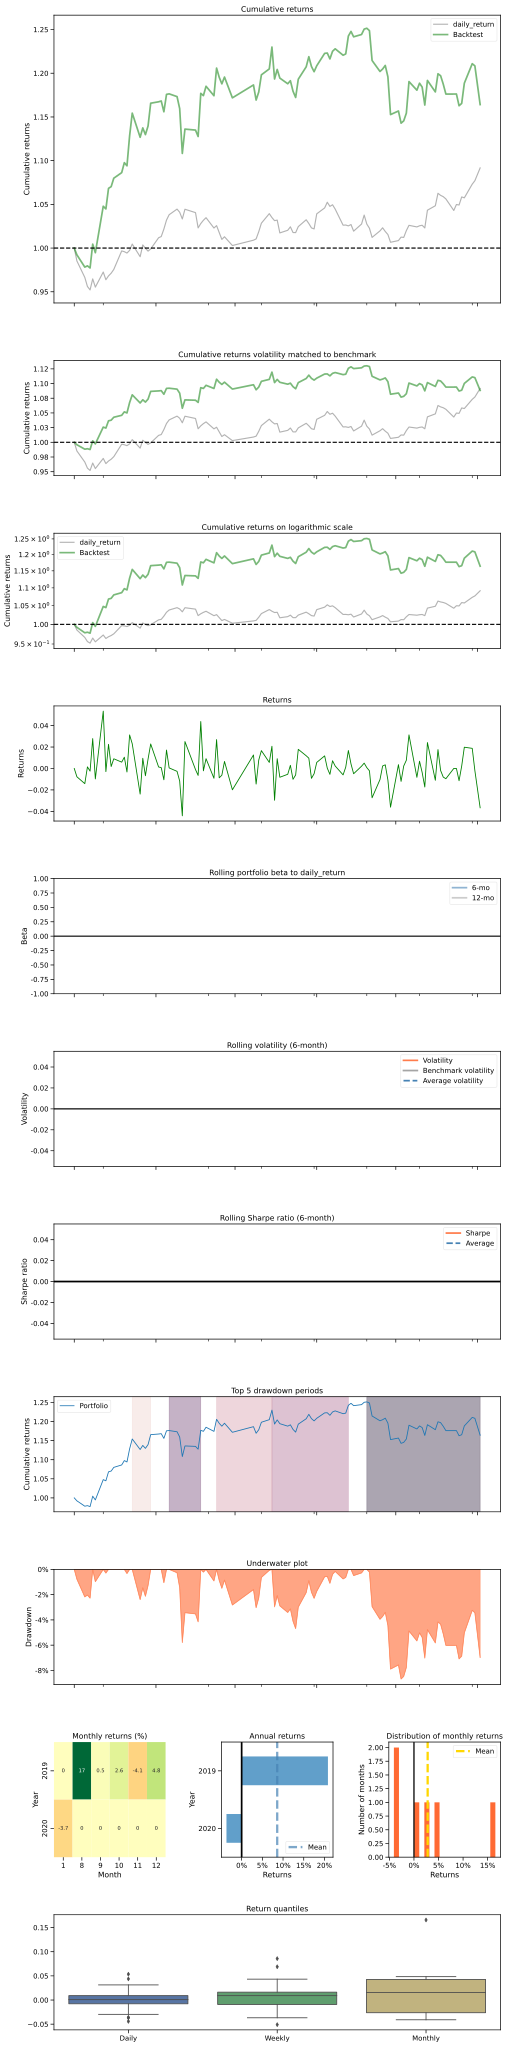

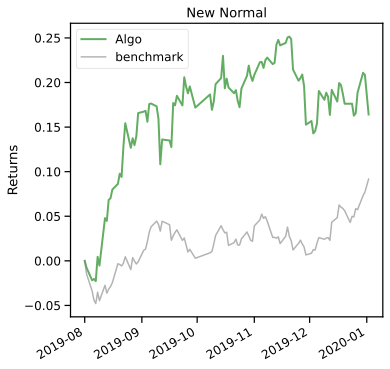

In [40]:
import pyfolio
%matplotlib inline 
df_daily_return = df_return_dict["TD3"]
DRL_strat = convert_daily_return_to_pyfolio_ts(df_daily_return)
DRL_strat.index = pd.to_datetime(DRL_strat.index.to_series().apply(lambda x:datetime.datetime.strftime(x, '%Y-%m-%d')))
# baseline_df = get_baseline(
#         ticker='^DJI', start=df_daily_return.loc[0,'date'], end='2021-11-01'
#     )

# baseline_returns = get_daily_return(baseline_df, value_col_name="close")

with pyfolio.plotting.plotting_context(font_scale=1.1, ):
        pyfolio.create_full_tear_sheet(returns = DRL_strat,
                                       benchmark_rets=baseline_returns, set_context=False)

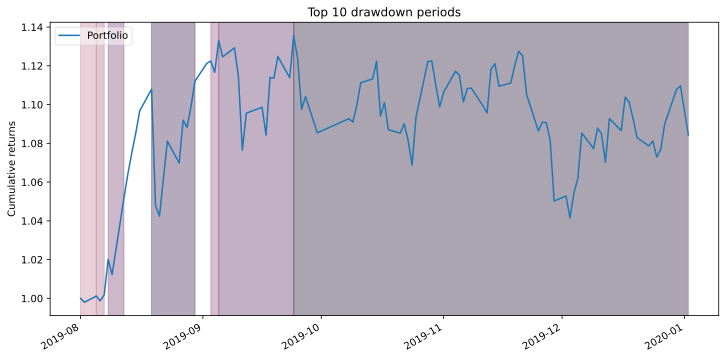

In [60]:
pyfolio.plot_drawdown_periods(returns = DRL_strat, figsize=(12, 6))
plt.savefig("a.png", dpi=300)

In [51]:
dir(pyfolio)

['APPROX_BDAYS_PER_MONTH',
 'FACTOR_PARTITIONS',
 'FigureCanvasAgg',
 'FuncFormatter',
 'MM_DISPLAY_UNIT',
 'Markdown',
 'OrderedDict',
 'STAT_FUNCS_PCT',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_seaborn',
 '_version',
 'axes_style',
 'capacity',
 'create_capacity_tear_sheet',
 'create_full_tear_sheet',
 'create_interesting_times_tear_sheet',
 'create_perf_attrib_tear_sheet',
 'create_position_tear_sheet',
 'create_returns_tear_sheet',
 'create_round_trip_tear_sheet',
 'create_simple_tear_sheet',
 'create_txn_tear_sheet',
 'customize',
 'datetime',
 'deprecate',
 'display',
 'division',
 'ep',
 'figure',
 'gridspec',
 'interesting_periods',
 'matplotlib',
 'np',
 'patches',
 'pd',
 'perf_attrib',
 'plot_annual_returns',
 'plot_capacity_sweep',
 'plot_cones',
 'plot_daily_turnover_hist',
 'plot_daily_volume',
 'plot_drawdown_periods',
 'plot_drawdown_underwater',
 'plot_e

### Plotly: DRL,CSI300

In [36]:
from datetime import datetime as dt

import matplotlib.pyplot as plt
import plotly
import plotly.graph_objs as go

In [37]:
time_ind = pd.Series(df_daily_return.date)

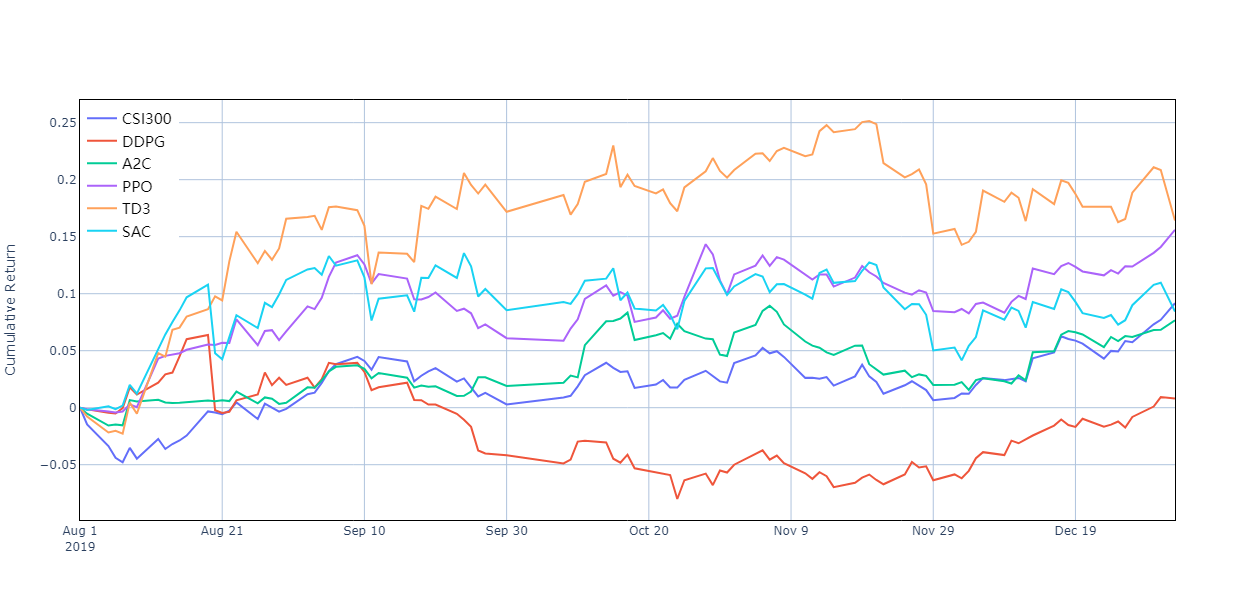

In [73]:
fig = go.Figure()
trace0_portfolio = go.Scatter(x = time_ind, y = csi_cumpod, mode = 'lines', name = 'CSI300')
fig.add_trace(trace0_portfolio)
for model_name, cumpod in df_cumpod_dict.items():
    trace_portfolio = go.Scatter(x = time_ind, y = cumpod, mode = 'lines', name = model_name)
    fig.add_trace(trace_portfolio)
# trace2_portfolio = go.Scatter(x = time_ind, y = min_var_cumpod, mode = 'lines', name = 'Min-Variance')
# trace3_portfolio = go.Scatter(x = time_ind, y = ddpg_cumpod, mode = 'lines', name = 'DDPG')
#trace4_portfolio = go.Scatter(x = time_ind, y = addpg_cumpod, mode = 'lines', name = 'Adaptive-DDPG')
#trace5_portfolio = go.Scatter(x = time_ind, y = min_cumpod, mode = 'lines', name = 'Min-Variance')

#trace4 = go.Scatter(x = time_ind, y = addpg_cumpod, mode = 'lines', name = 'Adaptive-DDPG')

#trace2 = go.Scatter(x = time_ind, y = portfolio_cost_minv, mode = 'lines', name = 'Min-Variance')
#trace3 = go.Scatter(x = time_ind, y = spx_value, mode = 'lines', name = 'SPX')

fig.update_layout(
    legend=dict(
        x=0,
        y=1,
        traceorder="normal",
        font=dict(
            family="sans-serif",
            size=15,
            color="black"
        ),
        bgcolor="White",
        bordercolor="white",
        borderwidth=2
        
    ),
)
#fig.update_layout(legend_orientation="h")
fig.update_layout(title={
        #'text': "Cumulative Return using FinRL",
        'y':0.85,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
#with Transaction cost
#fig.update_layout(title =  'Quarterly Trade Date')
fig.update_layout(
#    margin=dict(l=20, r=20, t=20, b=20),
    width=1200,
    height=600,
    paper_bgcolor='rgba(1,1,0,0)',
    plot_bgcolor='rgba(1, 1, 0, 0)',
    #xaxis_title="Date",
    yaxis_title="Cumulative Return",
xaxis={'type': 'date', 
       'tick0': time_ind[0], 
        'tickmode': 'linear', 
       'dtick': 86400000.0 *20}

)
fig.update_xaxes(showline=True,linecolor='black',showgrid=True, gridwidth=1, gridcolor='LightSteelBlue',mirror=True)
fig.update_yaxes(showline=True,linecolor='black',showgrid=True, gridwidth=1, gridcolor='LightSteelBlue',mirror=True)
fig.update_yaxes(zeroline=True, zerolinewidth=1, zerolinecolor='LightSteelBlue')

fig.show()